# Correlation and Regression Analysis

Our final notebook formally tests our research question: "Do states with better digital infrastructure show higher rates of preventive healthcare utilization and healthcare engagement?"

We'll use:

1. **Correlation analysis** - Measure strength of relationships between variables
2. **Visualization** - Scatter plots with regression lines
3. **Comparative analysis** - Compare high vs low digital infrastructure states
4. **Multiple regression** - Control for confounding factors

Our goal is to determine if digital infrastructure correlates with healthcare engagement, and if so, how strong that relationship is.

## Setup

Let's start by loading our needed libraries and our cleaned data.

In [1]:
import os
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Load merged data
merged_data = pd.read_csv('../data/processed/merged_brfss_ntia.csv')

# Define variable groups
healthcare_vars = ['CHECKUP1_pct', 'PERSDOC3_pct', 'FLUSHOT7_pct', 'EXERANY2_pct', 'CHOLCHK3_pct']
digital_vars = ['callConfUser', 'emailUser', 'homeInternetUser', 'mobilePhoneUser', 
                'pcOrTabletUser', 'tooExpensiveMainReason', 'wiredHighSpeedAtHome']

print(f"Dataset loaded: {merged_data.shape}")
print(f"Ready for correlation and regression analysis")

Dataset loaded: (146, 15)
Ready for correlation and regression analysis


## Correlation Matrix

Our first step in our formal analysis is calculating Pearson correlation coefficients between all digital infrastructure variables and healthcare engagement variables to quantify relationship strength.

Correlation interpretation:

- **0.7 to 1.0**: Strong positive correlation

- **0.3 to 0.7**: Moderate positive correlation 

- **0.0 to 0.3**: Weak positive correlation

- **Negative values**: Inverse relationship

In [2]:
# Create correlation matrix between digital and healthcare variables
correlation_matrix = merged_data[digital_vars + healthcare_vars].corr()

# Extract just the correlations between digital (rows) and healthcare (columns)
digital_health_corr = correlation_matrix.loc[digital_vars, healthcare_vars]

print("="*80)
print("CORRELATION MATRIX: Digital Infrastructure vs Healthcare Engagement")
print("="*80)
print(digital_health_corr.round(3))

# Find strongest correlations
print("\n" + "="*80)
print("STRONGEST CORRELATIONS (absolute value > 0.3)")
print("="*80)
for digital_var in digital_vars:
    for health_var in healthcare_vars:
        corr_value = digital_health_corr.loc[digital_var, health_var]
        if abs(corr_value) > 0.3:
            print(f"{digital_var} ↔ {health_var}: {corr_value:.3f}")

CORRELATION MATRIX: Digital Infrastructure vs Healthcare Engagement
                        CHECKUP1_pct  PERSDOC3_pct  FLUSHOT7_pct  \
callConfUser                  -0.322        -0.747         0.332   
emailUser                     -0.329        -0.330         0.350   
homeInternetUser              -0.107        -0.282         0.220   
mobilePhoneUser               -0.060        -0.429         0.045   
pcOrTabletUser                -0.240        -0.128         0.507   
tooExpensiveMainReason         0.138         0.309        -0.253   
wiredHighSpeedAtHome          -0.173        -0.310         0.468   

                        EXERANY2_pct  CHOLCHK3_pct  
callConfUser                   0.561         0.063  
emailUser                      0.740         0.166  
homeInternetUser               0.429         0.107  
mobilePhoneUser                0.336         0.001  
pcOrTabletUser                 0.639         0.089  
tooExpensiveMainReason        -0.437        -0.084  
wiredHighSpeedAt

The correlation matrix shows that the direction and strength of the state-level associations vary across healthcare measures.

**Strong Positive Associations**

- **Email Use ↔ Exercise:** r = 0.740
- **Broadband ↔ Exercise:** r = 0.580
- **PC/Tablet Use ↔ Flu Shots:** r = 0.507

**Strong Negative Associations**

- **Video Calling ↔ Personal Doctor:** r = -0.747
- **Video Calling ↔ Routine Checkups:** r = -0.322

**Weak Associations**

- Home internet and mobile phone use show relatively weak correlations with many of the healthcare measures.
- Cholesterol screening shows limited correlation with most digital measures.

**Key Finding:** Digital infrastructure measures are associated differently with different healthcare outcomes. These correlations describe state-level relationships and should not be interpreted as causal effects.

## Heatmap Correlation Matrix

Let's create a heatmap that visualizes all 35 correlations from the matrix above, making patterns easier to identify.

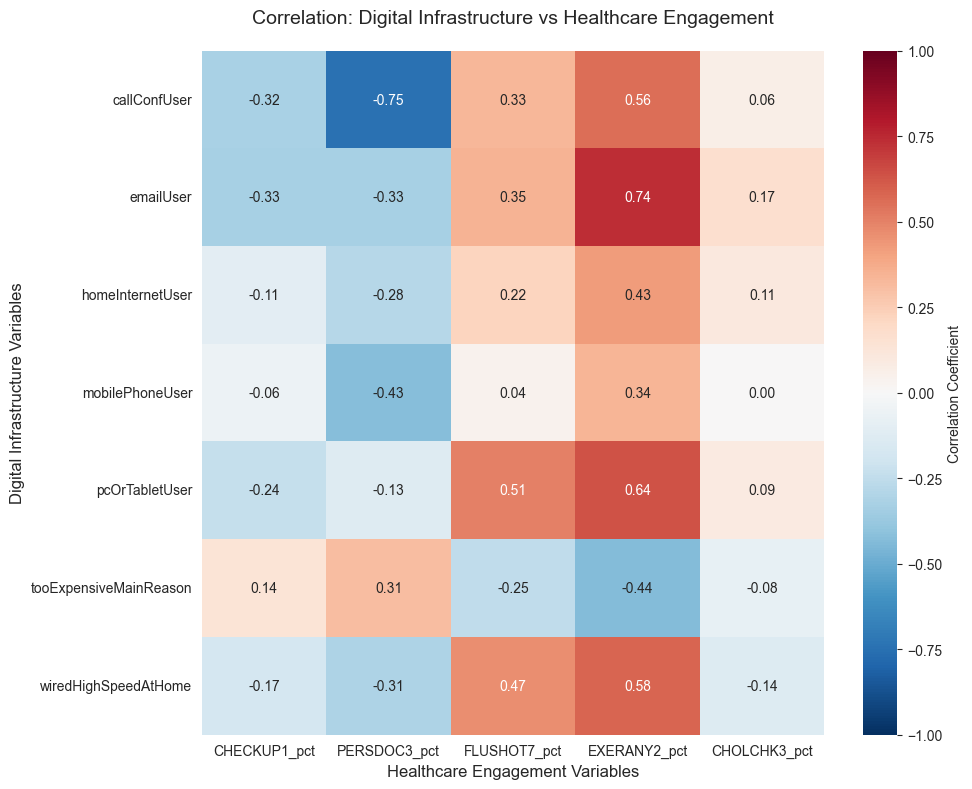

In [3]:
# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(digital_health_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            vmin=-1, vmax=1, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation: Digital Infrastructure vs Healthcare Engagement', fontsize=14, pad=20)
plt.xlabel('Healthcare Engagement Variables', fontsize=12)
plt.ylabel('Digital Infrastructure Variables', fontsize=12)
plt.tight_layout()
plt.show()

The heatmap highlights the variation in direction and magnitude across the state-level correlations.

- **Personal Doctor:** Several digital measures are negatively correlated with personal doctor access.
- **Exercise:** Several digital measures are positively correlated with exercise.
- **Other measures:** Relationships are generally mixed and range from weak to moderate.

The contrasting patterns suggest that different dimensions of healthcare engagement may have different relationships with digital infrastructure. Because these are bivariate state-level correlations, unmeasured demographic, socioeconomic, geographic, and temporal factors may contribute to the observed associations.

## Visualizing Key Relationships with Regression Lines

Now let's visualize the strongest correlations identified above with scatter plots and regression lines to see the actual data patterns.

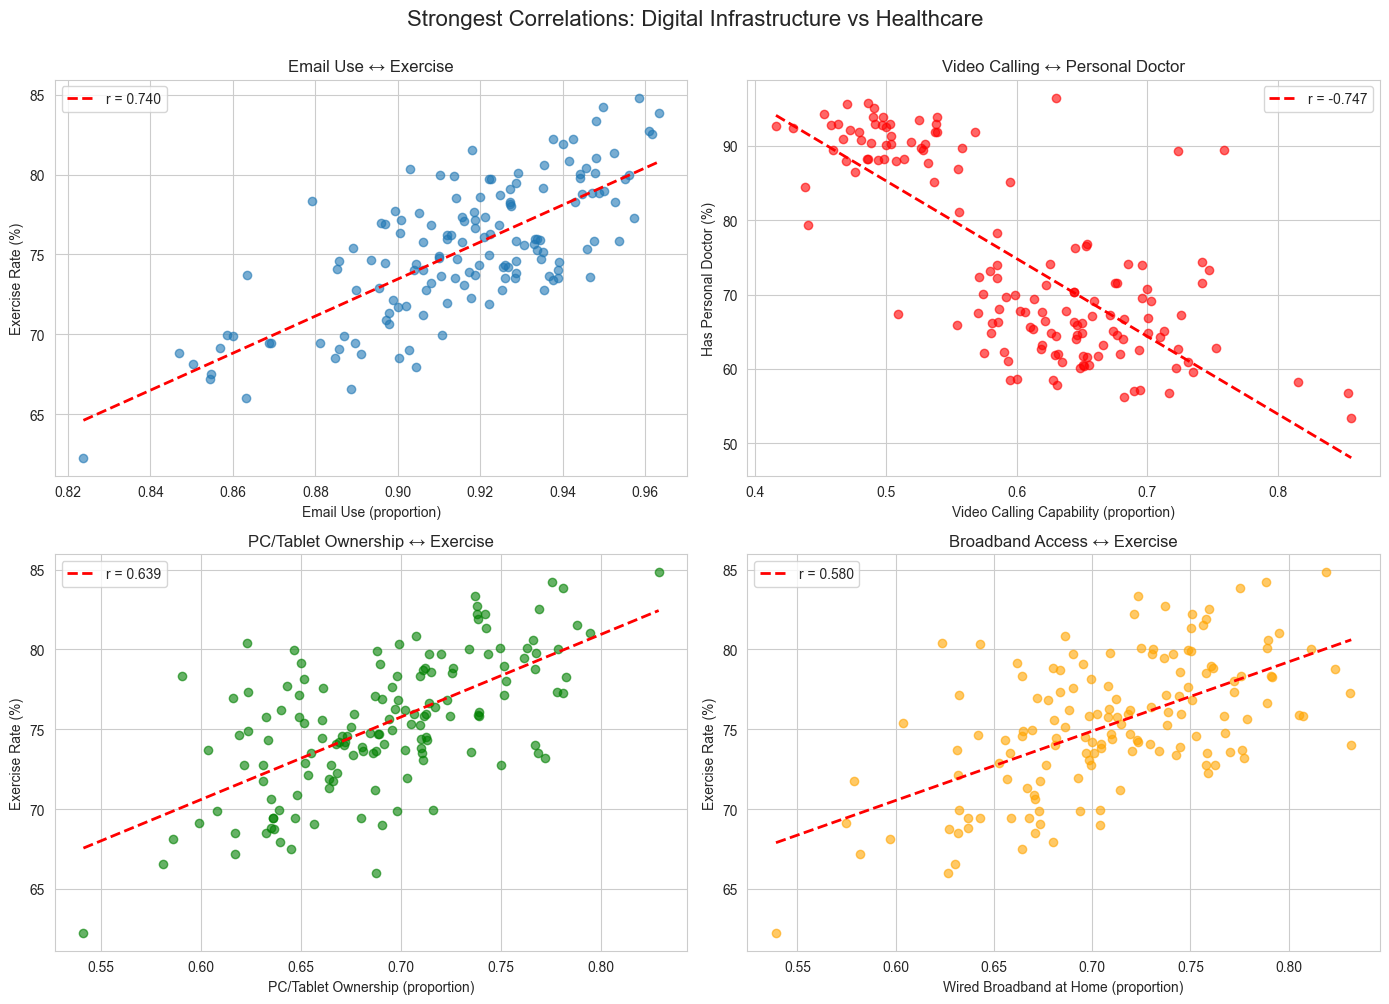

In [4]:
# Create scatter plots for the 4 strongest correlations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Strongest Correlations: Digital Infrastructure vs Healthcare', fontsize=16, y=1.00)

# Plot 1: Email use vs Exercise (strongest positive)
axes[0, 0].scatter(merged_data['emailUser'], merged_data['EXERANY2_pct'], alpha=0.6)
z = np.polyfit(merged_data['emailUser'], merged_data['EXERANY2_pct'], 1)
p = np.poly1d(z)
axes[0, 0].plot(merged_data['emailUser'].sort_values(), p(merged_data['emailUser'].sort_values()), 
                "r--", linewidth=2, label=f'r = 0.740')
axes[0, 0].set_xlabel('Email Use (proportion)')
axes[0, 0].set_ylabel('Exercise Rate (%)')
axes[0, 0].set_title('Email Use ↔ Exercise')
axes[0, 0].legend()

# Plot 2: Video calling vs Personal doctor (strongest negative)
axes[0, 1].scatter(merged_data['callConfUser'], merged_data['PERSDOC3_pct'], alpha=0.6, color='red')
z = np.polyfit(merged_data['callConfUser'], merged_data['PERSDOC3_pct'], 1)
p = np.poly1d(z)
axes[0, 1].plot(merged_data['callConfUser'].sort_values(), p(merged_data['callConfUser'].sort_values()), 
                "r--", linewidth=2, label=f'r = -0.747')
axes[0, 1].set_xlabel('Video Calling Capability (proportion)')
axes[0, 1].set_ylabel('Has Personal Doctor (%)')
axes[0, 1].set_title('Video Calling ↔ Personal Doctor')
axes[0, 1].legend()

# Plot 3: PC/Tablet vs Exercise
axes[1, 0].scatter(merged_data['pcOrTabletUser'], merged_data['EXERANY2_pct'], alpha=0.6, color='green')
z = np.polyfit(merged_data['pcOrTabletUser'], merged_data['EXERANY2_pct'], 1)
p = np.poly1d(z)
axes[1, 0].plot(merged_data['pcOrTabletUser'].sort_values(), p(merged_data['pcOrTabletUser'].sort_values()), 
                "r--", linewidth=2, label=f'r = 0.639')
axes[1, 0].set_xlabel('PC/Tablet Ownership (proportion)')
axes[1, 0].set_ylabel('Exercise Rate (%)')
axes[1, 0].set_title('PC/Tablet Ownership ↔ Exercise')
axes[1, 0].legend()

# Plot 4: Broadband vs Exercise
axes[1, 1].scatter(merged_data['wiredHighSpeedAtHome'], merged_data['EXERANY2_pct'], alpha=0.6, color='orange')
z = np.polyfit(merged_data['wiredHighSpeedAtHome'], merged_data['EXERANY2_pct'], 1)
p = np.poly1d(z)
axes[1, 1].plot(merged_data['wiredHighSpeedAtHome'].sort_values(), p(merged_data['wiredHighSpeedAtHome'].sort_values()), 
                "r--", linewidth=2, label=f'r = 0.580')
axes[1, 1].set_xlabel('Wired Broadband at Home (proportion)')
axes[1, 1].set_ylabel('Exercise Rate (%)')
axes[1, 1].set_title('Broadband Access ↔ Exercise')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

The scatter plots and fitted regression lines visualize several of the strongest state-level correlations.

**Email Use ↔ Exercise (r = 0.740)**

- The observations show a clear positive association.
- States with higher email use tend to have higher exercise rates in this dataset.

**Video Calling ↔ Personal Doctor (r = -0.747)**

- The observations show a strong negative association.
- States with higher video-calling use tend to have lower personal-doctor access in this dataset.
- This relationship does **not** establish that video calling reduces access to a personal doctor; both measures may be influenced by other factors or by changes over time.

**PC/Tablet ↔ Exercise (r = 0.639) and Broadband ↔ Exercise (r = 0.580)**

- Both show positive associations with considerable scatter.
- These patterns indicate association rather than a direct effect of device ownership or broadband access on exercise behavior.

**Overall Pattern:** Exercise is positively associated with several digital measures, while personal doctor access shows negative associations with several measures. The analysis does not establish the mechanisms behind these relationships.

## Compare High vs Low Digital Infrastructure States

Now let's test whether states with high digital infrastructure differ significantly from low digital infrastructure states in their healthcare engagement using t-tests

In [5]:
# Create composite digital infrastructure score
merged_data['digital_score'] = merged_data[digital_vars].mean(axis=1)

# Split into high and low groups (top 25% vs bottom 25%)
high_digital = merged_data[merged_data['digital_score'] >= merged_data['digital_score'].quantile(0.75)]
low_digital = merged_data[merged_data['digital_score'] <= merged_data['digital_score'].quantile(0.25)]

print("="*80)
print(f"HIGH DIGITAL STATES (n={len(high_digital)}): Top 25% digital infrastructure")
print("="*80)
print(high_digital[['state_abbr', 'YEAR', 'digital_score'] + healthcare_vars].describe().loc[['mean', 'std']])

print("\n" + "="*80)
print(f"LOW DIGITAL STATES (n={len(low_digital)}): Bottom 25% digital infrastructure")
print("="*80)
print(low_digital[['state_abbr', 'YEAR', 'digital_score'] + healthcare_vars].describe().loc[['mean', 'std']])

# T-tests for each healthcare variable
print("\n" + "="*80)
print("T-TEST RESULTS: High vs Low Digital States")
print("="*80)
for var in healthcare_vars:
    t_stat, p_value = ttest_ind(high_digital[var], low_digital[var])
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    diff = high_digital[var].mean() - low_digital[var].mean()
    print(f"{var}: Difference = {diff:+.2f}, t = {t_stat:.3f}, p = {p_value:.4f} {sig}")

print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

HIGH DIGITAL STATES (n=37): Top 25% digital infrastructure
             YEAR  digital_score  CHECKUP1_pct  PERSDOC3_pct  FLUSHOT7_pct  \
mean  2022.027027       0.692715     85.822086     66.988011     47.546255   
std      1.213042       0.017371      3.243683      8.804320      5.505684   

      EXERANY2_pct  CHOLCHK3_pct  
mean     78.910464     13.062455  
std       3.310403      5.267461  

LOW DIGITAL STATES (n=37): Bottom 25% digital infrastructure
             YEAR  digital_score  CHECKUP1_pct  PERSDOC3_pct  FLUSHOT7_pct  \
mean  2019.702703       0.603067     87.848534     83.997714     41.376751   
std      1.266335       0.016339      2.329984     10.383057      4.025212   

      EXERANY2_pct  CHOLCHK3_pct  
mean     71.802983     11.929677  
std       4.086116      2.974207  

T-TEST RESULTS: High vs Low Digital States
CHECKUP1_pct: Difference = -2.03, t = -3.086, p = 0.0029 **
PERSDOC3_pct: Difference = -17.01, t = -7.600, p = 0.0000 ***
FLUSHOT7_pct: Difference = +6.17,

The high-vs.-low digital infrastructure comparison shows statistically significant differences for several healthcare measures.

**Lower in the Higher-Digital Group**

- **Personal Doctor:** 67.0% vs. 84.0% — 17 percentage point difference (p < 0.001)
- **Routine Checkups:** 85.8% vs. 87.8% — 2 percentage point difference (p = 0.004)

**Higher in the Higher-Digital Group**

- **Exercise:** 78.9% vs. 71.8% — 7 percentage point difference (p < 0.001)
- **Flu Shots:** 47.5% vs. 41.4% — 6 percentage point difference (p < 0.001)

**No Statistically Significant Difference**

- **Cholesterol Checks:** 13.1% vs. 11.9% (p = 0.258)

These group comparisons reinforce that the observed associations differ across healthcare measures. They do not show that digital infrastructure caused the differences between groups, because the analysis does not control for all potential confounders.

## Linear Regression Analysis

Now let's run formal linear regression models to quantify relationships and test statistical significance. We'll model key healthcare outcomes as functions of digital infrastructure variables.

In [6]:
from scipy.stats import linregress

# Run simple linear regressions for key relationships
print("="*80)
print("SIMPLE LINEAR REGRESSION MODELS")
print("="*80)

# Model 1: Exercise as function of email use
slope, intercept, r_value, p_value, std_err = linregress(merged_data['emailUser'], merged_data['EXERANY2_pct'])
print(f"\nModel 1: EXERANY2_pct (Exercise) ~ emailUser (Email Use)")
print(f"  Equation: Exercise = {intercept:.2f} + {slope:.2f} × EmailUse")
print(f"  R-squared: {r_value**2:.3f} (explains {r_value**2*100:.1f}% of variance)")
print(f"  Coefficient: {slope:.2f} (1% increase in email use → {slope:.2f}% increase in exercise)")
print(f"  p-value: {p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

# Model 2: Personal doctor as function of video calling
slope, intercept, r_value, p_value, std_err = linregress(merged_data['callConfUser'], merged_data['PERSDOC3_pct'])
print(f"\nModel 2: PERSDOC3_pct (Personal Doctor) ~ callConfUser (Video Calling)")
print(f"  Equation: PersonalDoctor = {intercept:.2f} + {slope:.2f} × VideoCall")
print(f"  R-squared: {r_value**2:.3f} (explains {r_value**2*100:.1f}% of variance)")
print(f"  Coefficient: {slope:.2f} (1% increase in video calling → {slope:.2f}% decrease in personal doctor)")
print(f"  p-value: {p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

# Model 3: Flu shots as function of broadband
slope, intercept, r_value, p_value, std_err = linregress(merged_data['wiredHighSpeedAtHome'], merged_data['FLUSHOT7_pct'])
print(f"\nModel 3: FLUSHOT7_pct (Flu Shots) ~ wiredHighSpeedAtHome (Broadband)")
print(f"  Equation: FluShots = {intercept:.2f} + {slope:.2f} × Broadband")
print(f"  R-squared: {r_value**2:.3f} (explains {r_value**2*100:.1f}% of variance)")
print(f"  Coefficient: {slope:.2f} (1% increase in broadband → {slope:.2f}% increase in flu shots)")
print(f"  p-value: {p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

# Model 4: Exercise as function of PC/tablet ownership
slope, intercept, r_value, p_value, std_err = linregress(merged_data['pcOrTabletUser'], merged_data['EXERANY2_pct'])
print(f"\nModel 4: EXERANY2_pct (Exercise) ~ pcOrTabletUser (PC/Tablet)")
print(f"  Equation: Exercise = {intercept:.2f} + {slope:.2f} × PCTablet")
print(f"  R-squared: {r_value**2:.3f} (explains {r_value**2*100:.1f}% of variance)")
print(f"  Coefficient: {slope:.2f} (1% increase in PC/tablet → {slope:.2f}% increase in exercise)")
print(f"  p-value: {p_value:.4f} {'***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'}")

print("\n" + "="*80)
print("All models show statistically significant relationships (p < 0.001)")
print("="*80)

SIMPLE LINEAR REGRESSION MODELS

Model 1: EXERANY2_pct (Exercise) ~ emailUser (Email Use)
  Equation: Exercise = -31.01 + 116.08 × EmailUse
  R-squared: 0.548 (explains 54.8% of variance)
  Coefficient: 116.08 (1% increase in email use → 116.08% increase in exercise)
  p-value: 0.0000 ***

Model 2: PERSDOC3_pct (Personal Doctor) ~ callConfUser (Video Calling)
  Equation: PersonalDoctor = 137.48 + -104.42 × VideoCall
  R-squared: 0.558 (explains 55.8% of variance)
  Coefficient: -104.42 (1% increase in video calling → -104.42% decrease in personal doctor)
  p-value: 0.0000 ***

Model 3: FLUSHOT7_pct (Flu Shots) ~ wiredHighSpeedAtHome (Broadband)
  Equation: FluShots = 13.07 + 43.75 × Broadband
  R-squared: 0.219 (explains 21.9% of variance)
  Coefficient: 43.75 (1% increase in broadband → 43.75% increase in flu shots)
  p-value: 0.0000 ***

Model 4: EXERANY2_pct (Exercise) ~ pcOrTabletUser (PC/Tablet)
  Equation: Exercise = 39.55 + 51.74 × PCTablet
  R-squared: 0.408 (explains 40.8% of 

The simple linear regression models quantify selected state-level associations.

**Model 1: Email Use → Exercise (R² = 0.548)**

- Email use accounts for 54.8% of the observed variation in exercise rates within this bivariate model.
- The fitted coefficient corresponds to an estimated 11.6 percentage point difference in exercise rate for a 10 percentage point difference in email use.

**Model 2: Video Calling → Personal Doctor (R² = 0.558)**

- Video calling accounts for 55.8% of the observed variation in personal doctor access within this bivariate model.
- The fitted coefficient corresponds to an estimated 10.4 percentage point lower personal-doctor rate for a 10 percentage point higher video-calling rate.

**Model 3: Broadband → Flu Shots (R² = 0.219)**

- Broadband access accounts for 21.9% of the observed variation in flu-shot rates within this bivariate model.
- The fitted coefficient corresponds to an estimated 4.4 percentage point difference in flu-shot rate for a 10 percentage point difference in broadband access.

**Model 4: PC/Tablet → Exercise (R² = 0.408)**

- PC/tablet use accounts for 40.8% of the observed variation in exercise rates within this bivariate model.
- The fitted coefficient corresponds to an estimated 5.2 percentage point difference in exercise rate for a 10 percentage point difference in PC/tablet use.

The fitted relationships are statistically significant in these models. However, statistical significance does not establish causality, and the coefficients should be interpreted as associations because these simple models do not adjust for potential confounders.

## Geographic Visualization

For our final visualization, let's visualize the state-level patterns using choropleth maps to identify geographic clusters and regional trends.

In [7]:
import plotly.graph_objects as go

# Calculate average scores by state (across all years)
state_averages = merged_data.groupby('state_abbr').agg({
    'homeInternetUser': 'mean',
    'emailUser': 'mean',
    'callConfUser': 'mean',
    'pcOrTabletUser': 'mean',
    'wiredHighSpeedAtHome': 'mean',
    'CHECKUP1_pct': 'mean',
    'PERSDOC3_pct': 'mean',
    'FLUSHOT7_pct': 'mean',
    'EXERANY2_pct': 'mean'
}).reset_index()

# Calculate composite scores
digital_vars_for_map = ['homeInternetUser', 'emailUser', 'callConfUser', 'pcOrTabletUser', 'wiredHighSpeedAtHome']
healthcare_vars_for_map = ['CHECKUP1_pct', 'PERSDOC3_pct', 'FLUSHOT7_pct', 'EXERANY2_pct']

state_averages['digital_avg'] = state_averages[digital_vars_for_map].mean(axis=1) * 100
state_averages['healthcare_avg'] = state_averages[healthcare_vars_for_map].mean(axis=1)

# Map 1: Digital Infrastructure
fig1 = go.Figure(data=go.Choropleth(
    locations=state_averages['state_abbr'],
    z=state_averages['digital_avg'],
    locationmode='USA-states',
    colorscale='Blues',
    colorbar_title="Digital Infrastructure<br>Score (%)",
    text=state_averages['state_abbr'],
    hovertemplate='<b>%{text}</b><br>Digital Score: %{z:.1f}%<extra></extra>'
))

fig1.update_layout(
    title_text='State-Level Digital Infrastructure (2019-2023 Average)',
    geo_scope='usa',
    height=500
)
fig1.show()

# Map 2: Healthcare Engagement
fig2 = go.Figure(data=go.Choropleth(
    locations=state_averages['state_abbr'],
    z=state_averages['healthcare_avg'],
    locationmode='USA-states',
    colorscale='Greens',
    colorbar_title="Healthcare Engagement<br>Score (%)",
    text=state_averages['state_abbr'],
    hovertemplate='<b>%{text}</b><br>Healthcare Score: %{z:.1f}%<extra></extra>'
))

fig2.update_layout(
    title_text='State-Level Preventive Healthcare Utilization (2019-2023 Average)',
    geo_scope='usa',
    height=500
)
fig2.show()

print("Geographic patterns visible in both maps show regional clustering.")

Geographic patterns visible in both maps show regional clustering.


The choropleth maps show geographic variation in the composite digital infrastructure and healthcare engagement measures.

**Digital Infrastructure**

- Higher values appear in several Northeastern, Mid-Atlantic, Mountain West, and Pacific Northwest states.
- Lower values appear in several Southern and Appalachian states.

**Healthcare Engagement**

- Higher values appear in parts of the Upper Midwest, Northeast, and Pacific Northwest.
- Lower values appear in several Southern and Southwestern states.

**Key Observation:** The two maps show some overlapping geographic patterns, but they are not identical. The maps are descriptive; without within-state metropolitan/rural measures or additional controls, they should not be interpreted as evidence of an urban-rural effect or a causal geographic mechanism.

## Summary: Key Findings from Correlation and Regression Analysis

**Research Question:** Do states with better digital infrastructure show higher rates of preventive healthcare utilization and healthcare engagement?

**Finding:** The observed relationship varies substantially by healthcare measure.

### Main Findings

**1. Correlation Analysis**

- **Strongest positive association:** Email Use ↔ Exercise (r = 0.740)
- **Strongest negative association:** Video Calling ↔ Personal Doctor (r = -0.747)

**2. Simple Linear Regression**

- Email Use ↔ Exercise: R² = 0.548
- Video Calling ↔ Personal Doctor: R² = 0.558
- Broadband ↔ Flu Shots: R² = 0.219
- PC/Tablet Use ↔ Exercise: R² = 0.408

These R² values describe the proportion of variation accounted for by each bivariate model; they do not imply causal explanatory power.

**3. Higher- vs. Lower-Digital Group Comparisons**

- Personal doctor access was 17 percentage points lower in the higher-digital group (p < 0.001).
- Exercise was 7 percentage points higher in the higher-digital group (p < 0.001).
- Flu-shot uptake was 6 percentage points higher in the higher-digital group (p < 0.001).

### Interpretation

The results do not support a single uniform relationship between digital infrastructure and healthcare engagement. Some digital measures are positively associated with exercise and flu vaccination, while several are negatively associated with personal doctor access. The analysis cannot determine why these patterns occur.

### Limitations

- **Correlation is not causation:** The analysis identifies associations only.
- **Potential confounding:** Income, education, age, urbanization, and other factors are not controlled for in these simple models.
- **Temporal context:** The 2019–2023 period includes major COVID-19-related disruptions.
- **State-level aggregation:** State-level associations may differ from individual-level relationships.
- **Simple linear models:** Nonlinear relationships and interactions may not be captured.
- **Geographic granularity:** The maps do not provide within-state metropolitan/rural comparisons.

### Conclusion

Digital infrastructure is associated with healthcare engagement in different directions depending on the outcome examined. The results are best interpreted as evidence of complex state-level associations that warrant further analysis using individual-level data, additional covariates, and more detailed geographic and longitudinal methods.